# Эксперименты — сравнение моделей

Обучаем три модели (Dummy, LogisticRegression, RandomForest), сравниваем по метрикам на val-выборке, выбираем финальную модель.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)

from src.data.preprocess import load_raw, clean, build_encoders, encode, split, get_feature_names

sns.set_theme(style='whitegrid')

## 1. Подготовка данных

In [2]:
df = load_raw('../data/telco_churn.csv')
df = clean(df)
encoders = build_encoders(df)
df = encode(df, encoders)

X_train, X_val, X_test, y_train, y_val, y_test = split(df)
features = get_feature_names()
X_train, X_val, X_test = X_train[features], X_val[features], X_test[features]

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (4929, 19), Val: (705, 19), Test: (1409, 19)


## 2. Обучение моделей

In [3]:
models = {
    'Dummy (stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'Обучена: {name}')

Обучена: Dummy (stratified)
Обучена: LogisticRegression
Обучена: RandomForest


## 3. Сравнение по метрикам (Validation set)

In [4]:
rows = []
for name, model in trained.items():
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    rows.append({
        'Модель': name,
        'ROC-AUC': round(roc_auc_score(y_val, y_proba), 4),
        'F1': round(f1_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall': round(recall_score(y_val, y_pred), 4),
    })

df_results = pd.DataFrame(rows).set_index('Модель')
df_results

,ROC-AUC,F1,Precision,Recall
Модель,,,,
Dummy (stratified),0.4898,0.2480,0.2500,0.2460
LogisticRegression,0.8543,0.6291,0.7067,0.5668
RandomForest,0.8559,0.5714,0.6815,0.4920


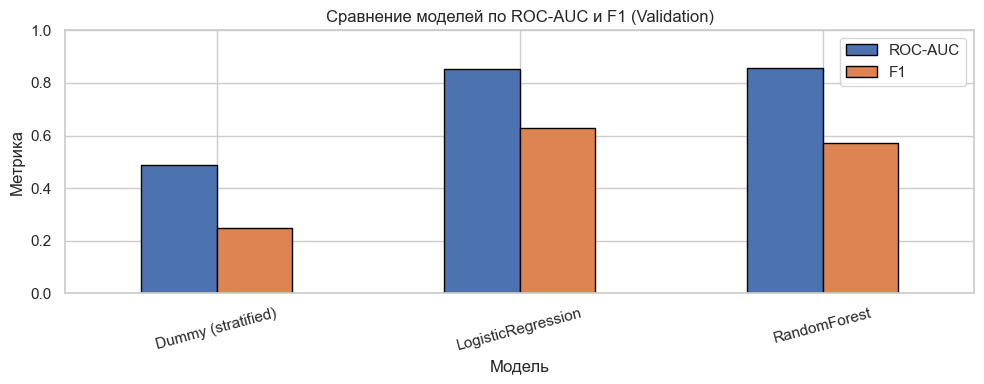

In [5]:
df_results[['ROC-AUC', 'F1']].plot(kind='bar', figsize=(10, 4), edgecolor='black')
plt.title('Сравнение моделей по ROC-AUC и F1 (Validation)')
plt.ylabel('Метрика')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. ROC-кривые

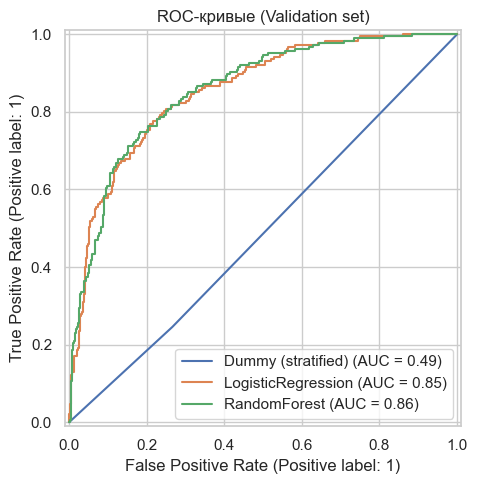

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in trained.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.set_title('ROC-кривые (Validation set)')
plt.tight_layout()
plt.show()

## 5. Матрица ошибок — финальная модель (RandomForest)

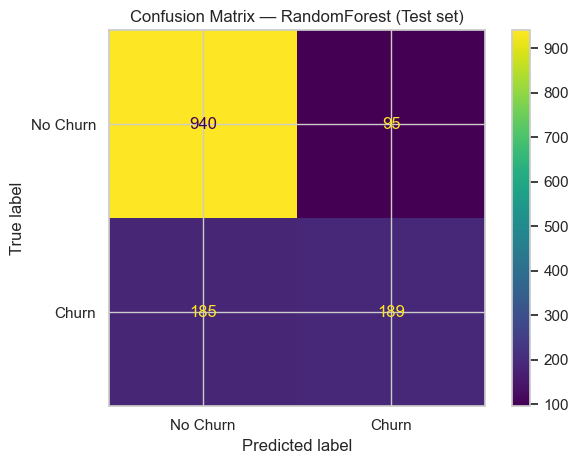

In [7]:
best_model = trained['RandomForest']
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=['No Churn', 'Churn']
)
plt.title('Confusion Matrix — RandomForest (Test set)')
plt.tight_layout()
plt.show()

## 6. Важность признаков

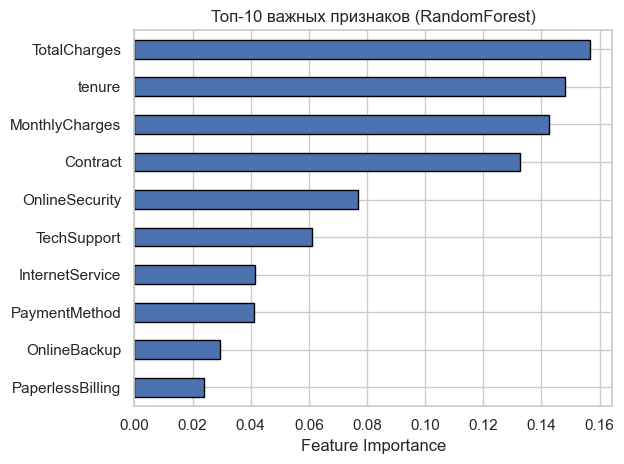

In [8]:
importances = pd.Series(
    best_model.feature_importances_, index=features
).sort_values(ascending=False)

importances.head(10).plot(kind='barh', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Топ-10 важных признаков (RandomForest)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## 7. Финальные метрики на тестовой выборке

In [9]:
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]
print('=== RandomForest | Test set ===')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba_test):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test):.4f}')

=== RandomForest | Test set ===
ROC-AUC:   0.8389
F1:        0.5745
Precision: 0.6655
Recall:    0.5053


## 8. Итог

Dummy предсказывает почти случайно (ROC-AUC 0.49) — это нижняя планка.

LogisticRegression уже нормально работает (0.85), но RandomForest чуть лучше по ROC-AUC (0.86) и заметно лучше по Precision — реже ошибается когда говорит что клиент уйдёт. Для задачи удержания это важно: звонить клиентам которые никуда не собирались — лишние расходы.

Ещё из feature importances видно что модель опирается в первую очередь на Contract и tenure, что совпадает с тем что было видно в EDA. Значит модель учит что-то разумное, а не мусор.

Взял RandomForest как финальную модель.